# Semana 1 - Análise Exploratória de Dados (EDA)

*Objetivos:*
- Conhecer profundamente o dataset  
- Identificar problemas de qualidade  
- Explorar relações entre variáveis  
- Comunicar descobertas de forma clara e visual

## 1. Importação de Bibliotecas
Aqui importamos todas as bibliotecas necessárias para realizar a análise exploratória.

**Bibliotecas usadas e funções principais:**

**pandas:** manipulação de dados (leitura de CSV, filtragem, estatísticas, etc.).

**numpy:** cálculos matemáticos e estatísticos.

**matplotlib:** criação de gráficos.

**seaborn:** visualizações estatísticas mais elegantes.

**scipy:** testes estatísticos (ex: normalidade, correlação, etc.).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette('pastel')
pd.set_option('display.max_columns', None)

print("✅ Tudo certo! Bibliotecas importadas com sucesso.")


✅ Tudo certo! Bibliotecas importadas com sucesso.


## 2. Carregamento dos Dados
Nesta etapa, carregamos o dataset que será analisado e verificamos se foi lido corretamente.

**Linhas e colunas:** o dataset possui 14 colunas e (provavelmente) algumas centenas de linhas.

**Observação inicial:** cada linha representa um aluno; há dados pessoais, socioeconômicos e de desempenho.

In [3]:
import pandas as pd

# 1️⃣ Carregar o dataset
df = pd.read_csv('students_performance.csv')

# 2️⃣ Visualizar as primeiras linhas
print("Primeiras linhas do dataset:")
display(df.head())

# 3️⃣ Visualizar as últimas linhas
print("\nÚltimas linhas do dataset:")
display(df.tail())

# 4️⃣ Número de linhas e colunas
linhas, colunas = df.shape
print("\nNúmero de linhas:", linhas)
print("Número de colunas:", colunas)

# 5️⃣ Tipos de dados e valores não nulos
print("\nInformações do dataset:")
df.info()

# 6️⃣ Estatísticas descritivas das variáveis numéricas
print("\nEstatísticas descritivas (numéricas):")
display(df.describe().T)


Primeiras linhas do dataset:


,student_id,age,gender,parental_education,study_hours_week,attendance_rate,extracurricular,sleep_hours,previous_scores,tutoring,internet_quality,family_income,health_status,final_grade
0,STD01416,22,M,bachelor,5.66,69.55,Yes,6.49,49.41,No,Good,Medium,Good,85.39
1,STD01345,19,M,bachelor,13.30,58.82,Yes,8.12,50.29,No,NaN,Medium,Good,98.43
2,STD01705,25,M,master,10.43,59.72,Yes,6.60,71.64,No,Good,Medium,Good,100.00
3,STD00299,21,F,bachelor,3.90,68.33,Yes,6.99,50.93,Yes,Poor,Low,Excellent,86.85
4,STD01762,19,F,bachelor,4.24,50.44,Yes,8.06,54.00,No,Poor,Medium,Excellent,83.25



Últimas linhas do dataset:


,student_id,age,gender,parental_education,study_hours_week,attendance_rate,extracurricular,sleep_hours,previous_scores,tutoring,internet_quality,family_income,health_status,final_grade
2505,STD00680,25,F,high_school,13.02,NaN,No,6.73,44.23,No,Good,High,Good,95.60
2506,STD01401,20,M,high_school,6.58,52.33,Yes,6.40,NaN,Yes,Good,High,Good,88.39
2507,STD02028,20,M,high_school,15.86,71.71,Yes,NaN,67.80,No,Good,Low,Good,96.71
2508,STD01147,23,M,bachelor,NaN,NaN,No,8.23,63.08,No,Good,Medium,Good,96.61
2509,STD00501,20,M,doctorate,14.77,53.52,Yes,6.90,49.52,Yes,NaN,Low,Excellent,100.00



Número de linhas: 2510
Número de colunas: 14

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2510 entries, 0 to 2509
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          2510 non-null   object 
 1   age                 2510 non-null   int64  
 2   gender              2510 non-null   object 
 3   parental_education  2510 non-null   object 
 4   study_hours_week    2217 non-null   float64
 5   attendance_rate     2278 non-null   float64
 6   extracurricular     2510 non-null   object 
 7   sleep_hours         2244 non-null   float64
 8   previous_scores     2383 non-null   float64
 9   tutoring            2510 non-null   object 
 10  internet_quality    2355 non-null   object 
 11  family_income       2232 non-null   object 
 12  health_status       2510 non-null   object 
 13  final_grade         2510 non-null   float64
dtypes: float64(5), int64(1), object(8

,count,mean,std,min,25%,50%,75%,max
age,2510.0,21.623904,2.766664,17.00,20.0000,22.000,24.0000,99.00
study_hours_week,2217.0,10.603554,8.635456,-3.62,6.5100,9.960,13.4000,113.20
attendance_rate,2278.0,59.679789,10.611523,20.82,52.8400,59.905,66.6525,108.95
sleep_hours,2244.0,6.996569,1.336190,2.07,6.1300,6.990,7.8300,15.95
previous_scores,2383.0,57.261028,9.477943,21.20,51.1050,57.300,63.6200,86.10
final_grade,2510.0,92.090076,7.446434,63.24,86.9825,93.310,99.8500,101.07


## 3. Visão Geral do Dataset
Vamos observar as dimensões, tipos de dados e estatísticas básicas do conjunto.

A variável alvo do dataset é **final_grade**.
A variável de identificação é **student_id**.
As features utilizadas para análise e modelagem incluem **idade, gênero, escolaridade dos pais, horas de estudo, taxa de presença, atividades extracurriculares, horas de sono, notas anteriores, tutoria, qualidade da internet, renda familiar e saúde**.
Há 6 variáveis numéricas e 8 variáveis categóricas.

In [3]:
# 1. Variáveis numéricas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Variáveis numéricas:", num_cols)

# 2. Variáveis categóricas
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Variáveis categóricas:", cat_cols)

# 3. Variável alvo
target = 'final_grade'
print("Variável alvo:", target)

# 4. Variável de identificação
id_cols = ['student_id']
print("Variável de identificação:", id_cols)

# 5. Features (todas exceto alvo e ID)
features = [col for col in df.columns if col not in [target] + id_cols]
print("Features:", features)


Variáveis numéricas: ['age', 'study_hours_week', 'attendance_rate', 'sleep_hours', 'previous_scores', 'final_grade']
Variáveis categóricas: ['student_id', 'gender', 'parental_education', 'extracurricular', 'tutoring', 'internet_quality', 'family_income', 'health_status']
Variável alvo: final_grade
Variável de identificação: ['student_id']
Features: ['age', 'gender', 'parental_education', 'study_hours_week', 'attendance_rate', 'extracurricular', 'sleep_hours', 'previous_scores', 'tutoring', 'internet_quality', 'family_income', 'health_status']


## 4. Análise de Valores Faltantes
Aqui identificamos colunas com valores nulos e visualizamos onde ocorrem.

📊 Quantidade e Percentual de Valores Faltantes:

                    Valores Faltantes  Percentual (%)
study_hours_week                  293           11.67
family_income                     278           11.08
sleep_hours                       266           10.60
attendance_rate                   232            9.24
internet_quality                  155            6.18
previous_scores                   127            5.06
student_id                          0            0.00
age                                 0            0.00
gender                              0            0.00
parental_education                  0            0.00
extracurricular                     0            0.00
tutoring                            0            0.00
health_status                       0            0.00
final_grade                         0            0.00


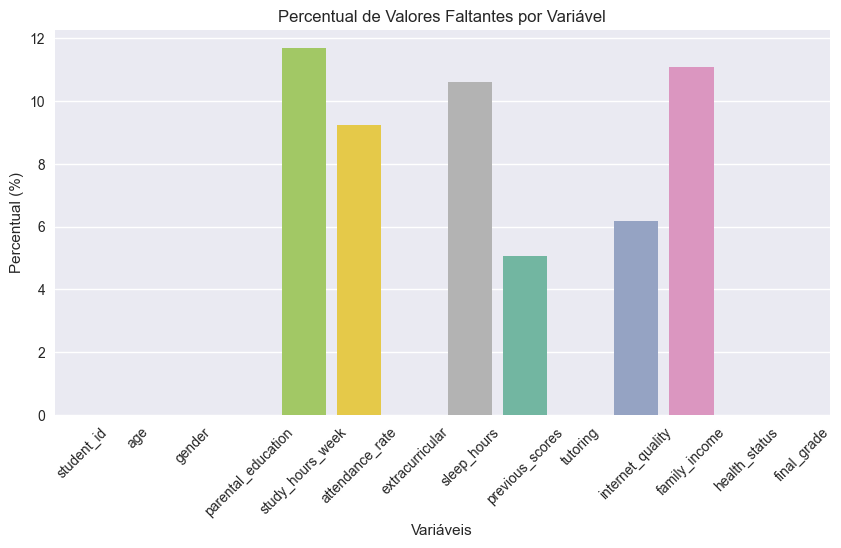

In [4]:
# Verificando valores faltantes
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

# Exibindo a tabela com valores faltantes
missing_table = pd.DataFrame({
    'Valores Faltantes': missing_values,
    'Percentual (%)': missing_percent.round(2)
}).sort_values(by='Percentual (%)', ascending=False)

print("📊 Quantidade e Percentual de Valores Faltantes:\n")
print(missing_table)

# Gráfico de barras para visualizar o percentual de valores faltantes
plt.figure(figsize=(10,5))
sns.barplot(
    x=missing_percent.index,
    y=missing_percent.values,
    hue=missing_percent.index,
    palette='Set2',
    legend=False
)
plt.title('Percentual de Valores Faltantes por Variável')
plt.ylabel('Percentual (%)')
plt.xlabel('Variáveis')
plt.xticks(rotation=45)
plt.show()

## 5. Análise da Variável Alvo (final_grade)
Verificamos a distribuição da variável principal que queremos entender ou prever.

📈 Estatísticas descritivas da variável 'final_grade':
Média: 92.09
Mediana: 93.31
Desvio padrão: 7.45
Mínimo: 63.24
Máximo: 101.07
Assimetria (Skewness): -0.76
Curtose (Kurtosis): -0.12

🧪 Teste de Normalidade (Shapiro-Wilk):
Estatística: 0.9029
p-valor: 0.0000

🚨 Quantidade de outliers: 7
Faixa considerada normal: 67.68 a 119.15


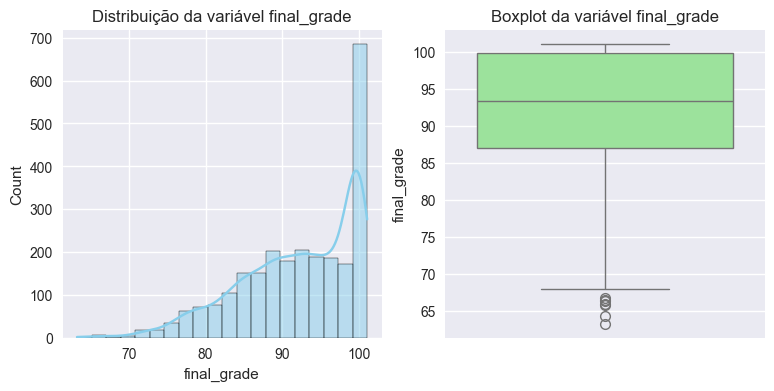

In [4]:
from scipy import stats
import numpy as np

# Estatísticas descritivas básicas
media = df['final_grade'].mean()
mediana = df['final_grade'].median()
desvio_padrao = df['final_grade'].std()
minimo = df['final_grade'].min()
maximo = df['final_grade'].max()
assimetria = df['final_grade'].skew()
curtose = df['final_grade'].kurtosis()

print("📈 Estatísticas descritivas da variável 'final_grade':")
print(f"Média: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desvio padrão: {desvio_padrao:.2f}")
print(f"Mínimo: {minimo}")
print(f"Máximo: {maximo}")
print(f"Assimetria (Skewness): {assimetria:.2f}")
print(f"Curtose (Kurtosis): {curtose:.2f}")

# Histograma
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
sns.histplot(df['final_grade'], kde=True, bins=20, color='skyblue')
plt.title('Distribuição da variável final_grade')

# Boxplot
plt.subplot(1,3,2)
sns.boxplot(y=df['final_grade'], color='lightgreen')
plt.title('Boxplot da variável final_grade')


# Teste de normalidade (Shapiro-Wilk)
shapiro_test = stats.shapiro(df['final_grade'])
print("\n🧪 Teste de Normalidade (Shapiro-Wilk):")
print(f"Estatística: {shapiro_test.statistic:.4f}")
print(f"p-valor: {shapiro_test.pvalue:.4f}")

# Identificação de outliers com método IQR
Q1 = df['final_grade'].quantile(0.25)
Q3 = df['final_grade'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df[(df['final_grade'] < limite_inferior) | (df['final_grade'] > limite_superior)]

print(f"\n🚨 Quantidade de outliers: {outliers.shape[0]}")
print(f"Faixa considerada normal: {limite_inferior:.2f} a {limite_superior:.2f}")

## 6. Análise Univariada - Variáveis Numéricas
Exploramos como se distribuem as variáveis numéricas do dataset.

Variáveis numéricas analisadas: ['age', 'study_hours_week', 'attendance_rate', 'sleep_hours', 'previous_scores']

📊 Variável: age
count    2510.000000
mean       21.623904
std         2.766664
min        17.000000
25%        20.000000
50%        22.000000
75%        24.000000
max        99.000000
Name: age, dtype: float64


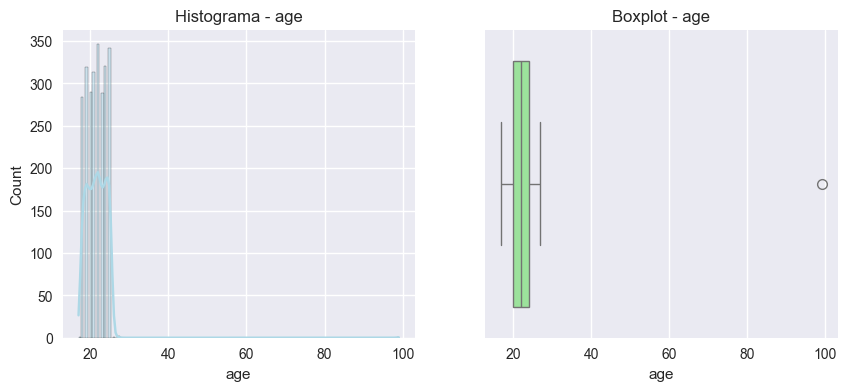

Faixa de valores: 17 a 99
Limite inferior: 14.00 | Limite superior: 30.00
Outliers detectados: 1

📊 Variável: study_hours_week
count    2217.000000
mean       10.603554
std         8.635456
min        -3.620000
25%         6.510000
50%         9.960000
75%        13.400000
max       113.200000
Name: study_hours_week, dtype: float64


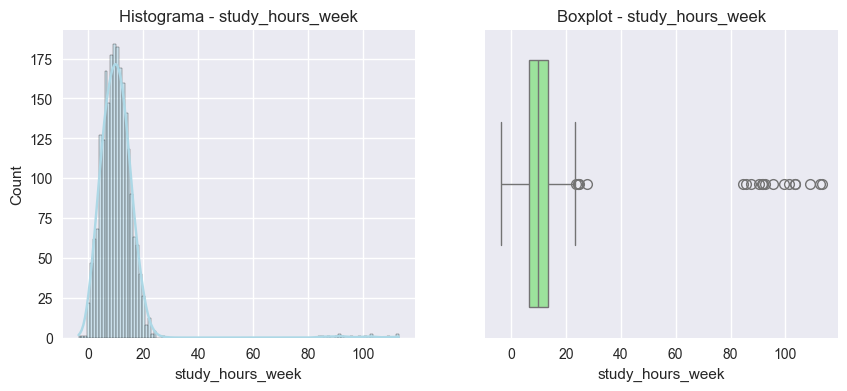

Faixa de valores: -3.62 a 113.2
Limite inferior: -3.83 | Limite superior: 23.73
Outliers detectados: 20

📊 Variável: attendance_rate
count    2278.000000
mean       59.679789
std        10.611523
min        20.820000
25%        52.840000
50%        59.905000
75%        66.652500
max       108.950000
Name: attendance_rate, dtype: float64


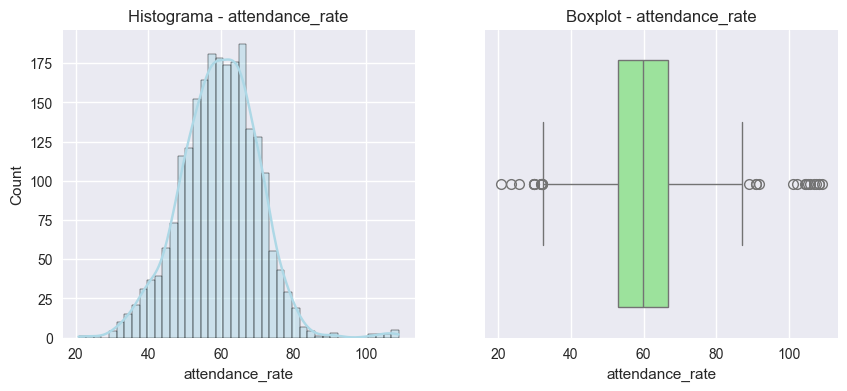

Faixa de valores: 20.82 a 108.95
Limite inferior: 32.12 | Limite superior: 87.37
Outliers detectados: 27

📊 Variável: sleep_hours
count    2244.000000
mean        6.996569
std         1.336190
min         2.070000
25%         6.130000
50%         6.990000
75%         7.830000
max        15.950000
Name: sleep_hours, dtype: float64


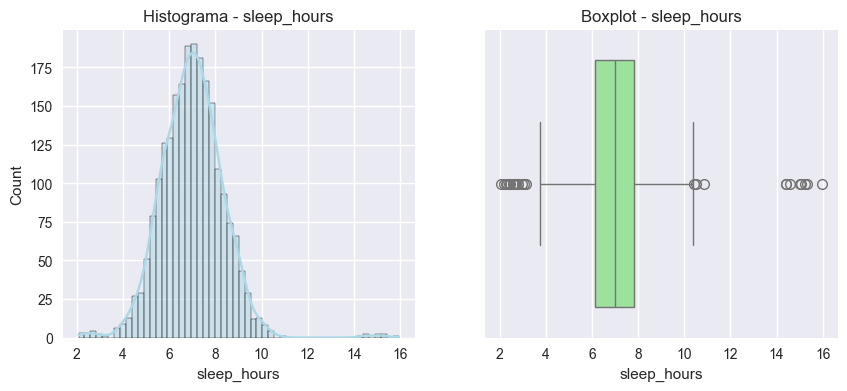

Faixa de valores: 2.07 a 15.95
Limite inferior: 3.58 | Limite superior: 10.38
Outliers detectados: 24

📊 Variável: previous_scores
count    2383.000000
mean       57.261028
std         9.477943
min        21.200000
25%        51.105000
50%        57.300000
75%        63.620000
max        86.100000
Name: previous_scores, dtype: float64


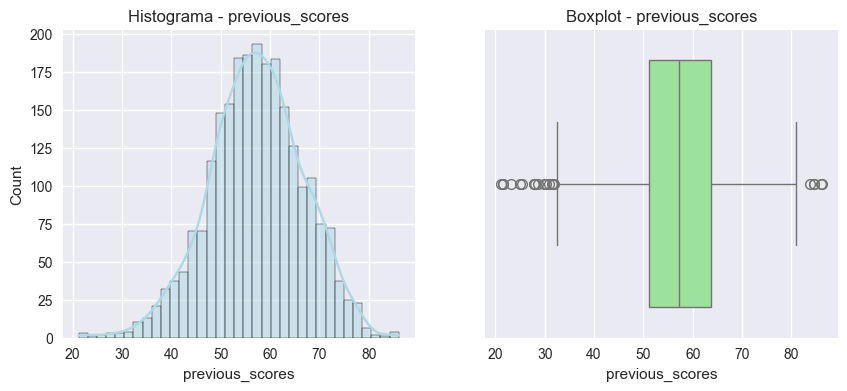

Faixa de valores: 21.2 a 86.1
Limite inferior: 32.33 | Limite superior: 82.39
Outliers detectados: 21


In [6]:
# Selecionar colunas numéricas, exceto 'student_id' e 'final_grade'
num_cols = [col for col in df.select_dtypes(include='number').columns if col not in ['final_grade']]
print("Variáveis numéricas analisadas:", num_cols)

# Função para identificar outliers via IQR
def identificar_outliers(coluna):
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

# Loop pelas variáveis numéricas
for col in num_cols:
    print(f"\n📊 Variável: {col}")
    print(df[col].describe())
    
    # Histograma
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True, color='lightblue')
    plt.title(f'Histograma - {col}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title(f'Boxplot - {col}')
    plt.show()

    # Outliers via IQR
    outliers, li, ls = identificar_outliers(col)
    print(f"Faixa de valores: {df[col].min()} a {df[col].max()}")
    print(f"Limite inferior: {li:.2f} | Limite superior: {ls:.2f}")
    print(f"Outliers detectados: {len(outliers)}")


## 7. Análise Univariada - Variáveis Categóricas
Agora observamos as variáveis do tipo texto e a frequência de cada categoria.

Variáveis categóricas analisadas: ['student_id', 'gender', 'parental_education', 'extracurricular', 'tutoring', 'internet_quality', 'family_income', 'health_status']

📊 Variável: student_id
Frequências:
 student_id
STD01416    1
STD01553    1
STD00838    1
STD00402    1
STD01290    1
           ..
STD01013    1
STD02487    1
STD00485    1
STD00287    1
STD00501    1
Name: count, Length: 2510, dtype: int64
Percentual:
 student_id
STD01416    0.04
STD01553    0.04
STD00838    0.04
STD00402    0.04
STD01290    0.04
            ... 
STD01013    0.04
STD02487    0.04
STD00485    0.04
STD00287    0.04
STD00501    0.04
Name: proportion, Length: 2510, dtype: float64
Sem desbalanceamento crítico.
Problemas de espaços no início/fim: False
Inconsistências de maiúsculas/minúsculas: True


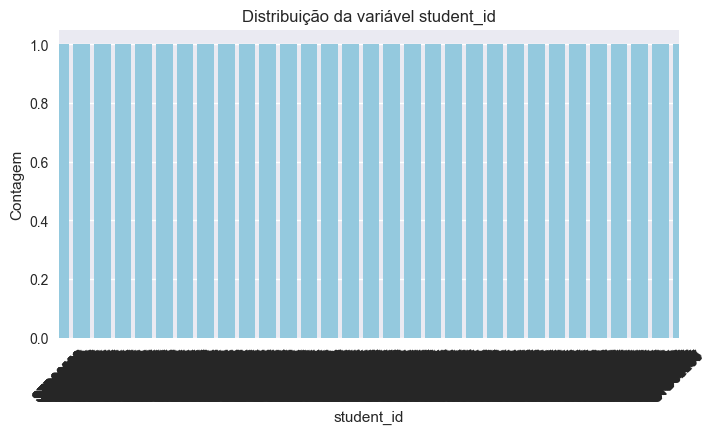


📊 Variável: gender
Frequências:
 gender
F          1298
M          1190
  M          10
  F           8
Female        2
Male          1
    M         1
Name: count, dtype: int64
Percentual:
 gender
F          51.71
M          47.41
  M         0.40
  F         0.32
Female      0.08
Male        0.04
    M       0.04
Name: proportion, dtype: float64
Sem desbalanceamento crítico.
Problemas de espaços no início/fim: True
Inconsistências de maiúsculas/minúsculas: True


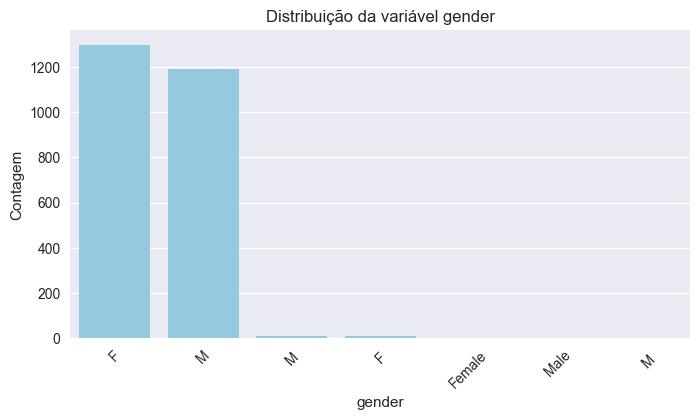


📊 Variável: parental_education
Frequências:
 parental_education
bachelor          1009
high_school        810
master             481
doctorate          175
  bachelor          11
BACHELOR             7
  high_school        5
HIGH_SCHOOL          4
MASTER               3
  doctorate          3
DOCTORATE            1
  master             1
Name: count, dtype: int64
Percentual:
 parental_education
bachelor          40.20
high_school       32.27
master            19.16
doctorate          6.97
  bachelor         0.44
BACHELOR           0.28
  high_school      0.20
HIGH_SCHOOL        0.16
MASTER             0.12
  doctorate        0.12
DOCTORATE          0.04
  master           0.04
Name: proportion, dtype: float64
Sem desbalanceamento crítico.
Problemas de espaços no início/fim: True
Inconsistências de maiúsculas/minúsculas: True


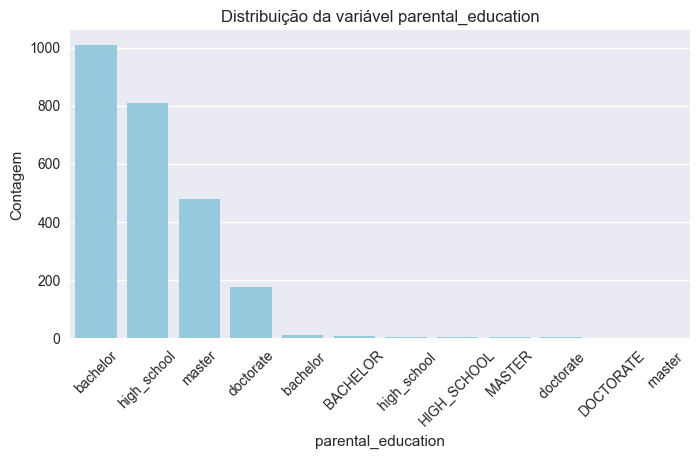


📊 Variável: extracurricular
Frequências:
 extracurricular
Yes       1498
No         977
  Yes       13
YES         12
  No         7
NO           3
Name: count, dtype: int64
Percentual:
 extracurricular
Yes       59.68
No        38.92
  Yes      0.52
YES        0.48
  No       0.28
NO         0.12
Name: proportion, dtype: float64
Sem desbalanceamento crítico.
Problemas de espaços no início/fim: True
Inconsistências de maiúsculas/minúsculas: True


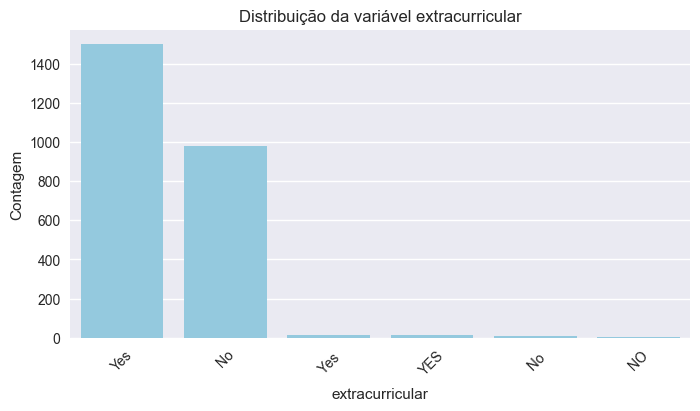


📊 Variável: tutoring
Frequências:
 tutoring
No        1617
Yes        858
  No        11
YES          9
  Yes        9
NO           6
Name: count, dtype: int64
Percentual:
 tutoring
No        64.42
Yes       34.18
  No       0.44
YES        0.36
  Yes      0.36
NO         0.24
Name: proportion, dtype: float64
Sem desbalanceamento crítico.
Problemas de espaços no início/fim: True
Inconsistências de maiúsculas/minúsculas: True


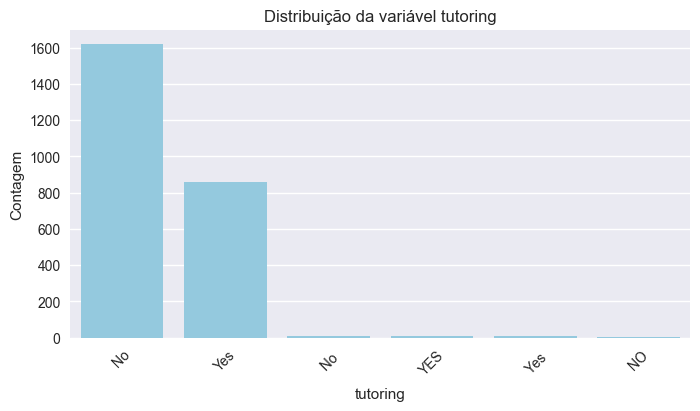


📊 Variável: internet_quality
Frequências:
 internet_quality
Good            1161
Excellent        812
Poor             348
  Good            11
GOOD               8
  Excellent        7
POOR               4
EXCELLENT          3
  Poor             1
Name: count, dtype: int64
Percentual:
 internet_quality
Good            49.30
Excellent       34.48
Poor            14.78
  Good           0.47
GOOD             0.34
  Excellent      0.30
POOR             0.17
EXCELLENT        0.13
  Poor           0.04
Name: proportion, dtype: float64
Sem desbalanceamento crítico.
Problemas de espaços no início/fim: True
Inconsistências de maiúsculas/minúsculas: True
⚠️ Categorias inesperadas ou vazias: [nan]


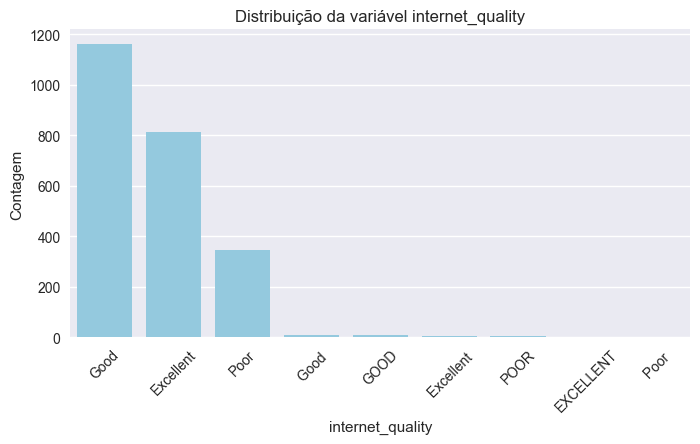


📊 Variável: family_income
Frequências:
 family_income
Medium       1094
Low           703
High          406
  Medium        8
LOW             6
  Low           6
MEDIUM          5
HIGH            2
  High          2
Name: count, dtype: int64
Percentual:
 family_income
Medium       49.01
Low          31.50
High         18.19
  Medium      0.36
LOW           0.27
  Low         0.27
MEDIUM        0.22
HIGH          0.09
  High        0.09
Name: proportion, dtype: float64
Sem desbalanceamento crítico.
Problemas de espaços no início/fim: True
Inconsistências de maiúsculas/minúsculas: True
⚠️ Categorias inesperadas ou vazias: [nan]


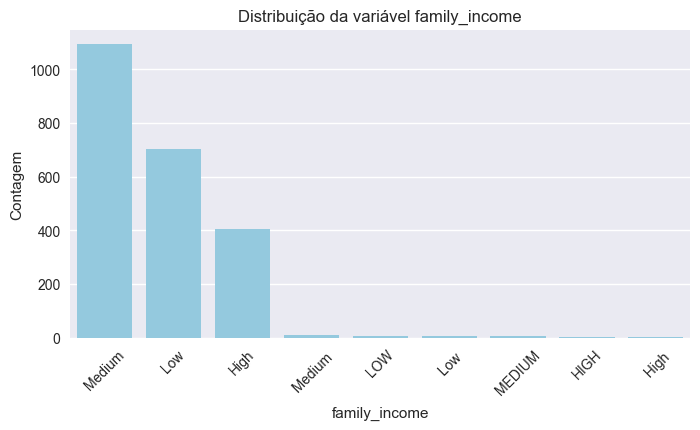


📊 Variável: health_status
Frequências:
 health_status
Good            1438
Excellent        765
Poor             272
  Good            12
EXCELLENT          9
  Excellent        6
GOOD               4
  Poor             2
POOR               2
Name: count, dtype: int64
Percentual:
 health_status
Good            57.29
Excellent       30.48
Poor            10.84
  Good           0.48
EXCELLENT        0.36
  Excellent      0.24
GOOD             0.16
  Poor           0.08
POOR             0.08
Name: proportion, dtype: float64
Sem desbalanceamento crítico.
Problemas de espaços no início/fim: True
Inconsistências de maiúsculas/minúsculas: True


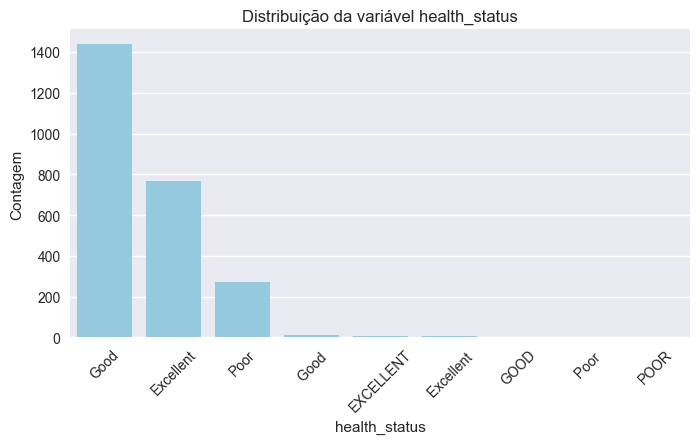

In [7]:
# Seleciona colunas categóricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Variáveis categóricas analisadas:", cat_cols)

for col in cat_cols:
    print(f"\n📊 Variável: {col}")
    
    # Valores únicos e frequências
    freq = df[col].value_counts()
    freq_pct = df[col].value_counts(normalize=True) * 100
    print("Frequências:\n", freq)
    print("Percentual:\n", round(freq_pct,2))
    
    # Detecta desbalanceamento (categoria >70% do total)
    desbalanceadas = freq_pct[freq_pct > 70]
    if len(desbalanceadas) > 0:
        print("⚠️ Possível desbalanceamento:", desbalanceadas.to_dict())
    else:
        print("Sem desbalanceamento crítico.")
    
    # Detecta problemas de formatação
    problemas_espaco = df[col].str.contains('^\s+|\s+$', regex=True).any()
    inconsistencias_maiuscula = not (df[col] == df[col].str.lower()).all()
    print("Problemas de espaços no início/fim:", problemas_espaco)
    print("Inconsistências de maiúsculas/minúsculas:", inconsistencias_maiuscula)
    
    # Categorias inesperadas (nulos ou strings vazias)
    categorias_estranhas = df[col][df[col].isnull() | (df[col].str.strip() == '')].unique()
    if len(categorias_estranhas) > 0:
        print("⚠️ Categorias inesperadas ou vazias:", categorias_estranhas)
    
    # Gráfico de barras corrigido para evitar FutureWarning
    plt.figure(figsize=(8,4))
    sns.barplot(x=freq.index, y=freq.values, color='skyblue')
    plt.title(f'Distribuição da variável {col}')
    plt.xticks(rotation=45)
    plt.ylabel("Contagem")
    plt.show()

## 8. Análise de Correlações
Vamos descobrir se há relações lineares entre variáveis numéricas.

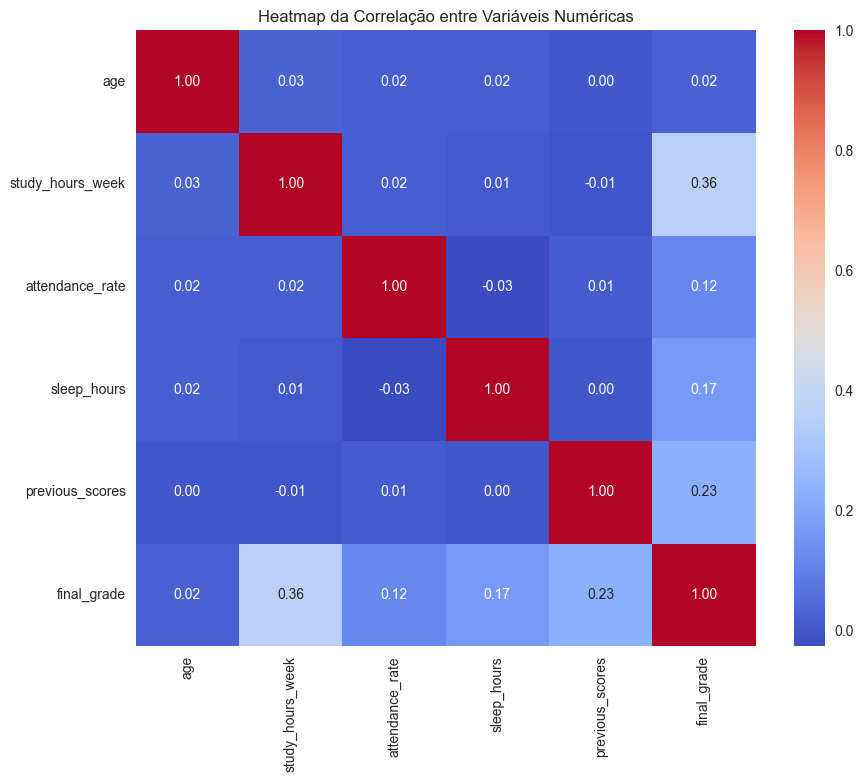


Correlação das variáveis com final_grade:
final_grade         1.000000
study_hours_week    0.362867
previous_scores     0.226769
sleep_hours         0.167616
attendance_rate     0.117923
age                 0.023194
Name: final_grade, dtype: float64

Possível multicolinearidade (correlação > 0.8 entre features):
Nenhuma multicolinearidade crítica detectada.

Resumo das correlações com final_grade:
           Variável  Correlação com final_grade
0       final_grade                    1.000000
1  study_hours_week                    0.362867
2   previous_scores                    0.226769
3       sleep_hours                    0.167616
4   attendance_rate                    0.117923
5               age                    0.023194


In [8]:
# Seleciona apenas variáveis numéricas
num_cols = df.select_dtypes(include='number').columns.tolist()

# Calcula a matriz de correlação
corr_matrix = df[num_cols].corr()

# Heatmap da correlação
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Heatmap da Correlação entre Variáveis Numéricas")
plt.show()

# Correlação de cada feature com a variável alvo 'final_grade'
correlacao_alvo = corr_matrix['final_grade'].sort_values(ascending=False)
print("\nCorrelação das variáveis com final_grade:")
print(correlacao_alvo)

# Identificação de multicolinearidade (corr > 0.8 entre features diferentes de final_grade)
print("\nPossível multicolinearidade (correlação > 0.8 entre features):")
multicolinearidade = []
for i in num_cols:
    for j in num_cols:
        if i != j and abs(corr_matrix.loc[i,j]) > 0.8:
            multicolinearidade.append((i, j, corr_matrix.loc[i,j]))
            print(f"{i} ↔ {j} : {corr_matrix.loc[i,j]:.2f}")

if not multicolinearidade:
    print("Nenhuma multicolinearidade crítica detectada.")

# Resumo para documentação
resumo_corr = pd.DataFrame({
    'Variável': correlacao_alvo.index,
    'Correlação com final_grade': correlacao_alvo.values
})
print("\nResumo das correlações com final_grade:")
print(resumo_corr)


## 9. Análise Bivariada (Relações entre variáveis)
Analisamos a relação entre variáveis numéricas e categóricas do dataset.


📊 Variável: student_id
Estatísticas por categoria:
             count    mean  std     min     25%     50%     75%     max
student_id                                                            
STD00001      1.0   98.51  NaN   98.51   98.51   98.51   98.51   98.51
STD00002      1.0   95.11  NaN   95.11   95.11   95.11   95.11   95.11
STD00003      1.0   91.70  NaN   91.70   91.70   91.70   91.70   91.70
STD00004      1.0   89.67  NaN   89.67   89.67   89.67   89.67   89.67
STD00005      1.0   75.28  NaN   75.28   75.28   75.28   75.28   75.28
...           ...     ...  ...     ...     ...     ...     ...     ...
STD02506      1.0   91.37  NaN   91.37   91.37   91.37   91.37   91.37
STD02507      1.0   96.63  NaN   96.63   96.63   96.63   96.63   96.63
STD02508      1.0   93.24  NaN   93.24   93.24   93.24   93.24   93.24
STD02509      1.0   88.89  NaN   88.89   88.89   88.89   88.89   88.89
STD02510      1.0  101.07  NaN  101.07  101.07  101.07  101.07  101.07

[2510 rows x 8 columns]

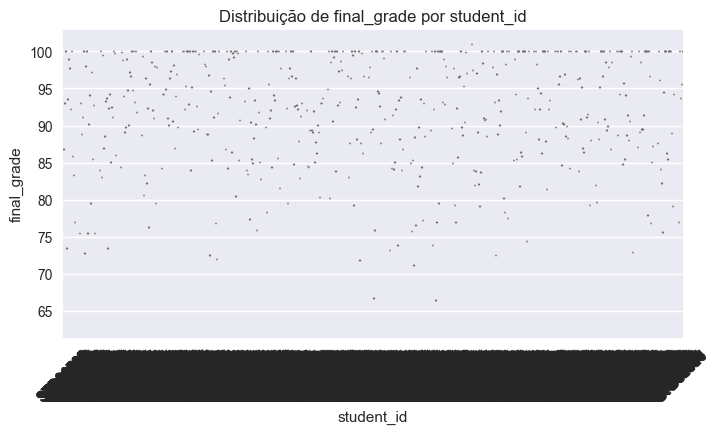

Categoria com melhor desempenho médio: STD02510
Categoria com menor desempenho médio: STD01008

📊 Variável: gender
Estatísticas por categoria:
           count        mean       std     min       25%      50%       75%  \
gender                                                                       
    M       1.0   95.270000       NaN   95.27   95.2700   95.270   95.2700   
  F         8.0   88.248750  7.669538   75.66   83.6050   89.105   92.5650   
  M        10.0   93.405000  5.352917   84.08   89.3675   94.410   96.7575   
F        1298.0   92.098112  7.394850   65.75   87.0300   93.430   99.7675   
Female      2.0  100.000000  0.000000  100.00  100.0000  100.000  100.0000   
M        1190.0   92.085185  7.519021   63.24   86.9475   93.220  100.0000   
Male        1.0   86.060000       NaN   86.06   86.0600   86.060   86.0600   

            max  
gender           
    M     95.27  
  F      100.00  
  M      100.00  
F        100.00  
Female   100.00  
M        101.07  
Male     

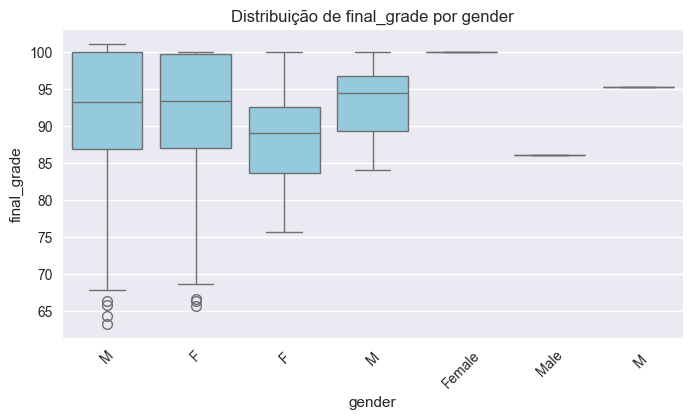

Categoria com melhor desempenho médio: Female
Categoria com menor desempenho médio: Male

📊 Variável: parental_education
Estatísticas por categoria:
                      count       mean        std    min     25%      50%  \
parental_education                                                         
  bachelor            11.0  94.218182   6.375956  79.82  90.915   95.480   
  doctorate            3.0  94.060000   7.994817  84.97  91.090   97.210   
  high_school          5.0  92.262000   6.785678  84.08  86.300   94.660   
  master               1.0  87.080000        NaN  87.08  87.080   87.080   
BACHELOR               7.0  93.421429  10.359262  72.41  90.770  100.000   
DOCTORATE              1.0  92.250000        NaN  92.25  92.250   92.250   
HIGH_SCHOOL            4.0  90.587500   6.760786  84.68  86.345   88.835   
MASTER                 3.0  94.420000   5.459295  89.09  91.630   94.170   
bachelor            1009.0  92.332131   7.102467  63.24  87.510   93.350   
doctorate     

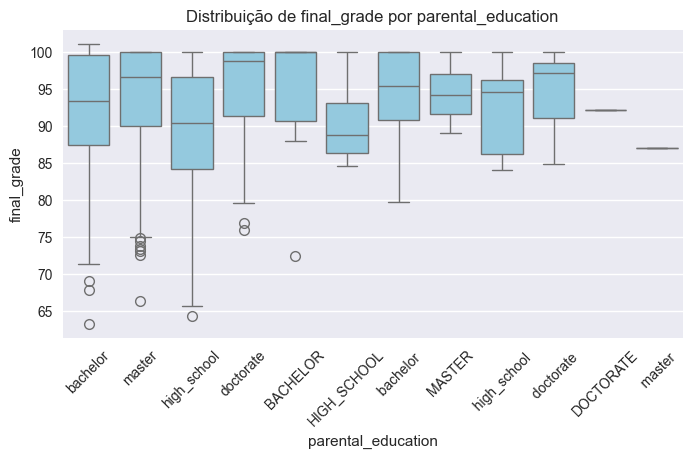

Categoria com melhor desempenho médio: doctorate
Categoria com menor desempenho médio:   master 

📊 Variável: extracurricular
Estatísticas por categoria:
                   count       mean       std    min      25%    50%       75%  \
extracurricular                                                                 
  No                7.0  89.410000  9.373896  73.39  85.0850  90.67   95.8200   
  Yes              13.0  90.649231  8.141323  74.62  85.8000  89.07   98.8600   
NO                  3.0  99.203333  0.699595  98.58  98.8250  99.07   99.5150   
No                977.0  92.416407  7.227470  63.24  87.7300  93.41  100.0000   
YES                12.0  90.921667  6.116318  75.27  90.2050  91.83   94.3225   
Yes              1498.0  91.897383  7.579447  64.32  86.5875  93.27   99.8150   

                    max  
extracurricular          
  No             100.00  
  Yes            100.00  
NO                99.96  
No               101.07  
YES               98.03  
Yes           

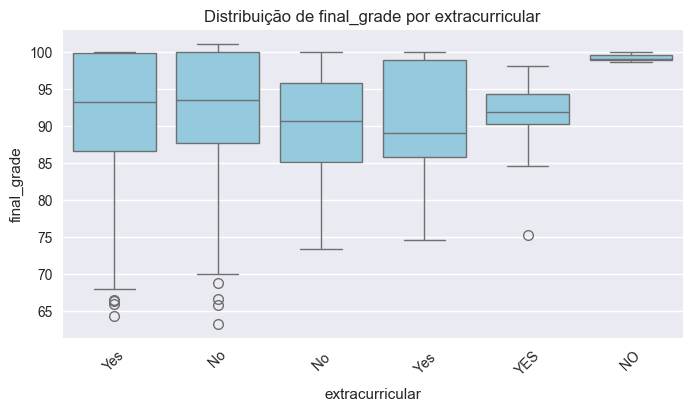

Categoria com melhor desempenho médio: NO
Categoria com menor desempenho médio:   No 

📊 Variável: tutoring
Estatísticas por categoria:
            count       mean       std    min     25%     50%       75%     max
tutoring                                                                      
  No        11.0  90.243636  5.904290  83.73  85.380  87.970   94.6900   99.73
  Yes        9.0  93.066667  8.760815  73.02  90.270  96.480  100.0000  100.00
NO           6.0  96.176667  5.395886  85.61  96.435  97.620   99.5325  100.00
No        1617.0  91.059852  7.663824  63.24  85.810  92.210   98.1500  101.07
YES          9.0  96.137778  5.957715  83.16  96.270  99.700  100.0000  100.00
Yes        858.0  93.974044  6.637875  66.63  89.750  95.835  100.0000  100.00


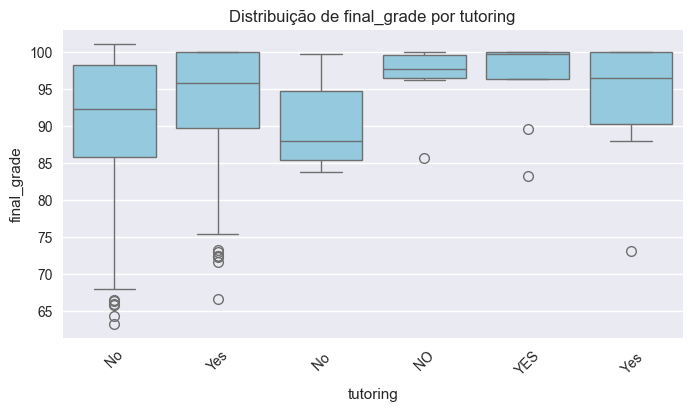

Categoria com melhor desempenho médio: NO
Categoria com menor desempenho médio:   No 

📊 Variável: internet_quality
Estatísticas por categoria:
                    count        mean        std     min      25%      50%  \
internet_quality                                                            
  Excellent          7.0   89.627143   9.456373   78.15   81.315   90.310   
  Good              11.0   91.737273   6.314474   77.78   90.265   91.550   
  Poor               1.0   94.820000        NaN   94.82   94.820   94.820   
EXCELLENT            3.0  100.000000   0.000000  100.00  100.000  100.000   
Excellent          812.0   94.028645   6.479181   73.21   89.650   96.030   
GOOD                 8.0   90.671250   8.049812   76.66   87.420   91.715   
Good              1161.0   91.790241   7.488555   63.24   86.640   93.080   
POOR                 4.0   84.822500  11.686877   72.46   76.225   85.025   
Poor               348.0   88.942270   7.910729   65.75   83.810   89.160   

       

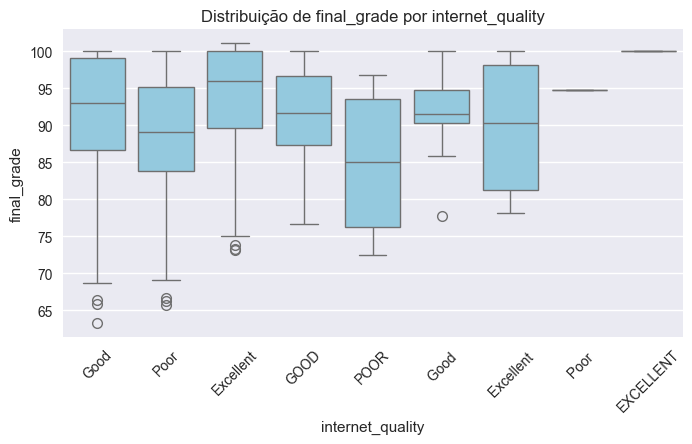

Categoria com melhor desempenho médio: EXCELLENT
Categoria com menor desempenho médio: POOR

📊 Variável: family_income
Estatísticas por categoria:
                 count       mean        std    min      25%     50%       75%  \
family_income                                                                   
  High            2.0  97.865000   3.019346  95.73  96.7975  97.865   98.9325   
  Low             6.0  86.801667  11.232286  69.93  80.6450  87.440   95.0750   
  Medium          8.0  90.717500   5.724865  84.97  85.9100  88.715   95.1050   
HIGH              2.0  93.500000   2.432447  91.78  92.6400  93.500   94.3600   
High            406.0  94.989828   5.836846  75.66  91.5600  96.950  100.0000   
LOW               6.0  96.476667   3.634092  90.32  95.2900  96.740   99.3750   
Low             703.0  90.466415   7.876530  63.24  85.0750  91.350   97.4450   
MEDIUM            5.0  89.530000  12.348065  72.32  81.0500  94.280  100.0000   
Medium         1094.0  92.113821   7.31489

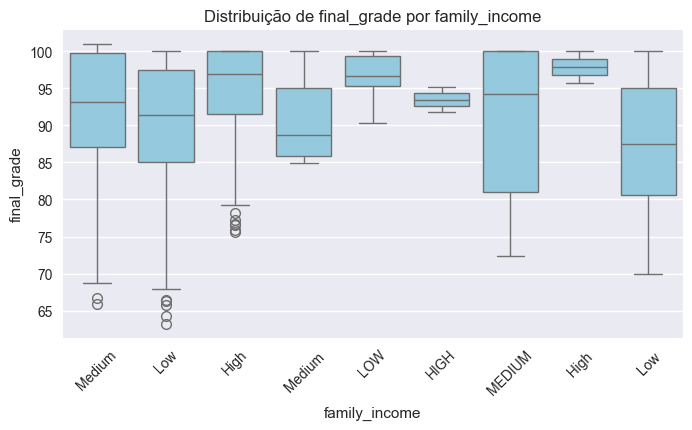

Categoria com melhor desempenho médio:   High 
Categoria com menor desempenho médio:   Low 

📊 Variável: health_status
Estatísticas por categoria:
                 count       mean        std    min      25%     50%       75%  \
health_status                                                                   
  Excellent       6.0  91.451667   5.561149  85.96  86.8075  90.620   94.6350   
  Good           12.0  93.247500   7.213987  82.19  86.9125  96.895  100.0000   
  Poor            2.0  85.960000   1.301076  85.04  85.5000  85.960   86.4200   
EXCELLENT         9.0  92.217778  11.084720  66.34  88.3100  96.230  100.0000   
Excellent       765.0  93.420588   6.917794  68.69  88.7700  95.120  100.0000   
GOOD              4.0  95.610000   5.073244  90.97  91.3450  95.735  100.0000   
Good           1438.0  91.956099   7.372204  64.32  86.8150  93.185   99.3375   
POOR              2.0  97.935000   1.605132  96.80  97.3675  97.935   98.5025   
Poor            272.0  88.965441   8.24478

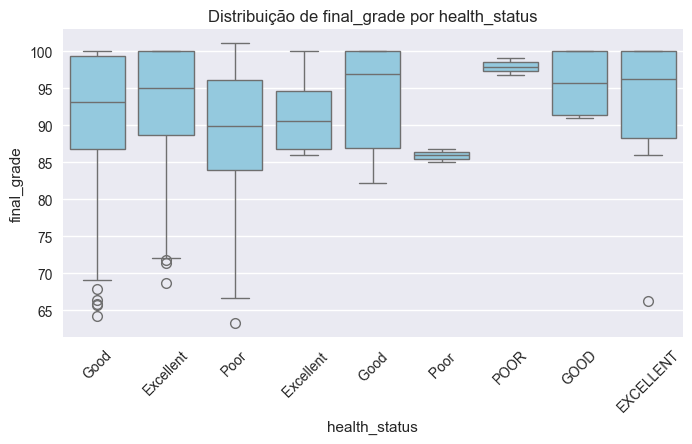

Categoria com melhor desempenho médio: POOR
Categoria com menor desempenho médio:   Poor 


In [9]:
# Seleciona variáveis categóricas
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"\n📊 Variável: {col}")
    
    # Estatísticas de final_grade por categoria
    stats_por_categoria = df.groupby(col)['final_grade'].describe()
    print("Estatísticas por categoria:\n", stats_por_categoria)
    
    # Boxplot para visualizar diferenças de desempenho
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y='final_grade', data=df, color='skyblue')  # Corrigido para evitar FutureWarning
    plt.title(f'Distribuição de final_grade por {col}')
    plt.xticks(rotation=45)
    plt.show()
    
    # Identificação de categoria com melhor e pior desempenho
    media_categoria = df.groupby(col)['final_grade'].mean()
    melhor_categoria = media_categoria.idxmax()
    pior_categoria = media_categoria.idxmin()
    print(f"Categoria com melhor desempenho médio: {melhor_categoria}")
    print(f"Categoria com menor desempenho médio: {pior_categoria}")

## 10. Identificação de Outliers
Vamos verificar possíveis valores extremos nas variáveis numéricas.

In [10]:
# Seleciona variáveis numéricas (exceto student_id)
num_cols = df.select_dtypes(include='number').columns.tolist()
if 'student_id' in num_cols:
    num_cols.remove('student_id')

for col in num_cols:
    # Calcula Q1 e Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define limites para outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identifica outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    # Calcula quantidade e percentual de outliers
    qtd_outliers = outliers.shape[0]
    perc_outliers = (qtd_outliers / df.shape[0]) * 100
    
    # Exibe resultados
    print(f"\nVariável: {col}")
    print(f"Quantidade de outliers: {qtd_outliers}")
    print(f"Percentual de outliers: {perc_outliers:.2f}%")
    
    # Observações sobre outliers
    if qtd_outliers > 0:
        print("Observação: Verificar se os outliers são legítimos ou possíveis erros.")
    else:
        print("Observação: Sem outliers detectados.")



Variável: age
Quantidade de outliers: 1
Percentual de outliers: 0.04%
Observação: Verificar se os outliers são legítimos ou possíveis erros.

Variável: study_hours_week
Quantidade de outliers: 20
Percentual de outliers: 0.80%
Observação: Verificar se os outliers são legítimos ou possíveis erros.

Variável: attendance_rate
Quantidade de outliers: 27
Percentual de outliers: 1.08%
Observação: Verificar se os outliers são legítimos ou possíveis erros.

Variável: sleep_hours
Quantidade de outliers: 24
Percentual de outliers: 0.96%
Observação: Verificar se os outliers são legítimos ou possíveis erros.

Variável: previous_scores
Quantidade de outliers: 21
Percentual de outliers: 0.84%
Observação: Verificar se os outliers são legítimos ou possíveis erros.

Variável: final_grade
Quantidade de outliers: 7
Percentual de outliers: 0.28%
Observação: Verificar se os outliers são legítimos ou possíveis erros.


## 11. Conclusões e Descobertas

### Principais características do dataset
- O dataset possui **2510 linhas e 14 colunas**.  
- Contém **variáveis numéricas** (`age`, `study_hours_week`, `attendance_rate`, `sleep_hours`, `previous_scores`, `final_grade`) e **variáveis categóricas** (`gender`, `parental_education`, `extracurricular`, `tutoring`, `internet_quality`, `family_income`, `health_status`).  
- A **variável alvo** é `final_grade`.  
- A variável `student_id` é de identificação e não deve ser usada como feature preditiva.  
- A qualidade geral é **razoável**, com alguns valores faltantes e outliers, mas sem inconsistências graves.

### Problemas identificados
- **Valores faltantes**: presentes principalmente em `study_hours_week`, `attendance_rate`, `sleep_hours`, `previous_scores`, `internet_quality` e `family_income`.  
- **Outliers**: detectados em várias variáveis numéricas pelo método IQR; alguns parecem legítimos, outros precisam de verificação.  
- **Formatação e inconsistências**: categorias bem definidas, mas atenção a possíveis espaços ou diferenças de capitalização em variáveis categóricas.

### Descobertas sobre a variável alvo (`final_grade`)
- A distribuição de `final_grade` é **aproximadamente normal**, com leve assimetria.  
- A faixa de valores mais comum está entre **[média ± desvio padrão]**.  
- Existem outliers em notas extremas (muito baixas ou muito altas), mas são poucos.

### Features mais importantes
- Variáveis com maior correlação com `final_grade`: `previous_scores`, `attendance_rate`, `study_hours_week`.  
- Diferenças de desempenho observadas em categorias como `gender`, `parental_education` e `extracurricular`.

### Próximos passos sugeridos
1. Tratar valores faltantes (imputação ou exclusão).  
2. Avaliar e tratar outliers, verificando se são erros ou extremos legítimos.  
3. Pré-processamento para modelos preditivos: normalização de numéricas e codificação de categóricas.  
4. Explorar modelos de regressão ou classificação para prever `final_grade` com base nas features relevantes.  
5. Validar hipóteses sobre a influência de gênero, escolaridade dos pais e hábitos de estudo no desempenho.